# Spatial effect — is $\alpha(t)$ still learnable when $\Sigma \neq I$?

**Finding so far** (`empirical_correlation.ipynb`): the inverted latents pass the per-pixel marginal checks but fail spatial independence — the radial spectrum is red (excess power at $|k|\lesssim 5$, deficit at mid-$k$), i.e. in practice $\varepsilon \sim \mathcal N(0, \Sigma)$ with $\Sigma \neq I$, and the spatial structure looks the same at every lead (Step 0c). On top of that, the scalar temporal correlation $\bar\rho(\Delta)$ decays **sub-exponentially** (concave on semilog — Step 2b): neither OU nor squared-exponential fits it.

**Question**: the Thread-3 plan (learn a marginal-preserving latent process, Andrae §3.4–3.6) assumes $\mathcal N(0, I)$ with "coordinates evolving independently". Does the $\Sigma \neq I$ reality break the learnability of $\alpha(t)$?

**Method** (`~/Documents/investigation.md`): do §3.4–3.6 in the **EOF / whitened basis** of $\Sigma$ instead of the pixel basis. Two identities drive everything. With $\Sigma = \sum_i \lambda_i v_i v_i^\top$ and per-mode autocorrelation $\rho_i(t) = v_i^\top C(t) v_i / \lambda_i$:

$$\hat\alpha(t) \;=\; \frac{\operatorname{tr} C(t)}{\operatorname{tr}\Sigma} \;=\; \sum_i w_i\,\rho_i(t), \qquad w_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

— the scalar §3.6 estimator is the **spatial-power-weighted average of the per-mode temporal autocorrelations**, and it never assumed $\Sigma = I$. So the question splits cleanly:

- **separable** ($C(t) = \alpha(t)\,\Sigma$): all $\rho_i(t)$ are the same curve, the blend collapses to it, and $\Sigma$ costs only estimator *variance*, never *bias*. One scalar $\alpha(t)$ is correct as-is.
- **non-separable** ($\rho_i(t)$ differ by mode): the scalar is a lossy mixture pulled toward the high-power modes, and the right object is a per-mode $\alpha_i(t)$ — still perfectly learnable, just scale-resolved.

For a doubly-periodic, near-isotropic field, the EOFs of a spatially-stationary $\Sigma$ are the 2-D **Fourier modes**, and isotropy ties eigenvalues to $|k|$ — so radial-wavenumber rings are the natural (and statistically robust) proxy for the eigenbasis. §B checks this claim empirically rather than assuming it.

| § | what | answers |
|---|---|---|
| A | ring spectrum $\lambda(k)$ of $\hat\Sigma$, lead-invariance, channel coherence | what $\Sigma$ looks like; is pooling over leads/channels legitimate |
| B | split-half empirical EOFs vs Fourier rings | is the ring proxy valid (+ Gate-1 Gaussianity in the whitened basis) |
| C | per-mode $\rho_k(\Delta)$ → **separability test** (doc §8) | curves collapse ⟹ scalar $\alpha(t)$; fan out ⟹ $\alpha(k,t)$ |
| D | blend identity, OLS vs GLS scalar | why $\bar\rho(\Delta)$ is concave; what the scalar actually estimates |
| E | per-ring OU fits → $r(k)$, nugget $g(k)$, $c_k^2 = 2r_k$ (doc §6) | the learned process + built-in misspecification flags |
| F | simulate the fitted process | marginal $\mathcal N(0,\hat\Sigma)$ preserved for all $t$; empirical $\bar\rho(\Delta)$ reproduced |
| G | robustness: N=64 @ 1000 steps vs N=387 @ 100 steps | are the rates inversion-artifact-free |

**Data**: `data/invert_steps=1000` — N=64 windows, leads $\tau = 1\ldots24$ h from a common anchor, the highest-fidelity inversion available (marginal std 0.975 vs 0.959 at 100 steps). ⚠ the saved latents are **already normalised** — loaded raw, never divide by 2660 again.

In [2]:
%matplotlib inline
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
from scipy import stats

DATA_PATH   = Path().resolve().parent / 'data'
PRIMARY_DIR = DATA_PATH / 'invert_steps=1000'   # N=64,  1000 Euler steps  (primary)
ROBUST_DIR  = DATA_PATH / 'invert'              # N=387,  100 Euler steps  (§G only)
cmap = plt.cm.viridis

def load_invert(dir_):
    '''One invert dir → Z (N, 24, 2, 64, 64), RAW (already in model units), + (traj, anchor) meta.'''
    files = natsorted(Path(dir_).glob('invert_traj*initial*.npy'))
    Z = np.stack([np.load(f).astype(np.float32) for f in files])
    meta = np.array([[int(m.group(1)), int(m.group(2))]
                     for f in files
                     for m in [re.search(r'invert_traj(\d+)initial(\d+)\.npy', f.name)]])
    return Z, meta

Z_raw, meta = load_invert(PRIMARY_DIR)
N, L, C, H, W = Z_raw.shape
d      = C * H * W                      # 8192
leads  = np.arange(1, L + 1)            # Z[:, j] ↔ lead τ = j+1 h
deltas = np.arange(1, L)                # lags Δ = 1 … 23 h

# Gate 1a: E[ε] ≈ 0, then center per (lead, pixel) across windows — removes the
# deterministic bias field that inversion under an imperfect drift dumps into ε.
print(f"Z: {Z_raw.shape}   mean {Z_raw.mean():+.4f}   std {Z_raw.std():.4f}   (0, 1 if inversion were exact)")
Zc = Z_raw - Z_raw.mean(axis=0, keepdims=True)

# ── scalar-estimator helpers (same math as empirical_correlation.ipynb) ──────
def gram_corr(Zin):
    '''Per-lead-CENTERED (n, L, ...) → per-sample lead×lead Grams normalised by
    the per-lead variances, plus those variances.'''
    Xf = Zin.reshape(Zin.shape[0], Zin.shape[1], -1).astype(np.float64)
    G  = np.einsum('nlx,nmx->nlm', Xf, Xf) / Xf.shape[-1]
    v  = np.diagonal(G.mean(axis=0)).copy()
    return G / np.sqrt(np.outer(v, v)), v

def collapse_by_lag(Gn):
    '''Per-sample mean over each superdiagonal Δ → ρ̄(Δ) with an honest sample SE.'''
    n, L_, _ = Gn.shape
    rho, se = np.empty(L_ - 1), np.empty(L_ - 1)
    for i, D in enumerate(range(1, L_)):
        per = np.diagonal(Gn, offset=D, axis1=1, axis2=2).mean(axis=1)
        rho[i], se[i] = per.mean(), per.std(ddof=1) / np.sqrt(n)
    return rho, se

Gn_grid, var_lead = gram_corr(Zc)
rho_grid, se_grid = collapse_by_lag(Gn_grid)
print(f"per-lead variance range: [{var_lead.min():.3f}, {var_lead.max():.3f}]   (1 if inversion were exact)")
print(f"scalar ρ̄(Δ=1) = {rho_grid[0]:.4f} ± {se_grid[0]:.4f}   — the curve §D will decompose")

Z: (64, 24, 2, 64, 64)   mean -0.0037   std 0.9726   (0, 1 if inversion were exact)
per-lead variance range: [0.854, 0.989]   (1 if inversion were exact)
scalar ρ̄(Δ=1) = 0.7182 ± 0.0061   — the curve §D will decompose


## A. The spatial covariance $\hat\Sigma$ in its (proxy) eigenbasis

For a spatially **stationary** field on a periodic grid, $\Sigma$ is diagonalised by the 2-D Fourier basis, and the eigenvalue attached to mode $k$ is its spectral density $\mathbb E|\hat z(k)|^2 / (HW)$. Under **isotropy** the eigenvalue depends only on $|k|$, so each integer ring of wavenumbers is one (near-)degenerate eigen-block of $\Sigma$ — that is the whole "EOF = ring" proxy, checked empirically in §B.

Below: $\lambda(k)$ = ring-averaged per-mode power in eigenvalue units, normalised by the field variance so that *white noise ($\Sigma = I$) ⟹ flat at 1*.

Two legitimacy checks for the pooling used everywhere downstream:
1. **pool over leads** — valid only if the spectrum is lead-invariant (Step 0c said yes visually; quantified here);
2. **pool over the two channels** in the trace — the trace ignores cross-channel structure; per-ring cross-channel **coherence** measures how much is being ignored (0 = channels uncorrelated at that scale).

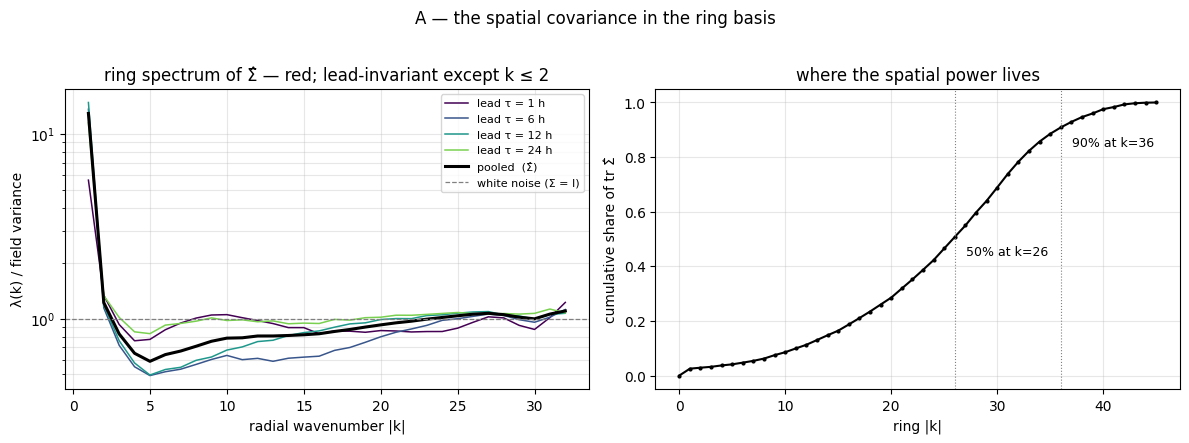

lead-invariance: max_τ,k |λ_τ(k)/λ(k) − 1| = 0.564, power-weighted mean 0.081   (per-ring sampling jitter alone ≈ 0.044 at k=1)
trace shares:  k≤2: 2.9%   k≤5: 4.1%   k≤8: 6.2%   DC: 0.01%   corner rings k>32: 21.69%
cross-channel coherence: max 0.509 at k=1, power-weighted mean 0.058   (noise floor ≈ 0.026)
largest deviation: ring k=1 at lead τ=1 h (λ_τ/λ̄ = 0.44);  k=1 density grows ×2.0 from lead 1 to 24 — the inversion dumps progressively more large-scale drift error at longer leads


In [ ]:
# ── ring (isotropic-EOF proxy) machinery ────────────────────────────────────
ky, kx = np.meshgrid(np.fft.fftfreq(H) * H, np.fft.fftfreq(W) * W, indexing='ij')
kr     = np.round(np.sqrt(kx**2 + ky**2)).astype(int)   # integer ring index per Fourier mode
B      = kr.max() + 1                                   # 46 rings: 0 = DC … 45 = grid corners
K_ISO  = H // 2                                         # rings 1…32 are the isotropic range; 33+ live in corners
# Actually, wavenumber and ring number they are same conceptions but just different scales
# In wavenumber, it thinks power over k=32 is small scales structure
# But for ring number, I can still investigate what the power look like generally.
ring_n = np.bincount(kr.ravel(), minlength=B)           # modes per ring (one channel)
m_b    = ring_n * C                                     # modes per ring incl. both channels
# Get ready for pooling over channels
# But I mean pooling over channels you should average over channels but not preserve the dimension right?
Zh     = np.fft.fft2(Zc, axes=(-2, -1))                 # (N, L, C, H, W) complex
# Zh is Z_k in my theoretical notation: it represents complex fourier coefficients for each (x, y)
# Here it has not performed coordinates convert
S_mode = (np.abs(Zh) ** 2).mean(axis=(0, 1))            # per-mode power E|ẑ|², pooled over leads  (C, H, W)
# This aims to compute eigenvalues on 2D-Fourier basis, namely spectral density
# which is lambda_k = E[||Z_k||**2]/HW
# But here it doesn't normalise, which means it's actually E[||Z_k||**2]
# TODO: If normalisation can be done over here, the code would be more readable

def ring_density(P2d):
    '''(…, H, W) per-mode power → (B,) ring-mean density in eigenvalue units E|ẑ|²/(HW).'''
    flat = P2d.reshape(-1, H * W).mean(axis=0) 
    # It pools everything here
    # It mapping into radial coordinates, dimension reduction applied by minlength=B which is 33
    # And also, it performed ring and pixels normalisation (Since it needs to compute the density, so pooling all ring numbers)
    return np.bincount(kr.ravel(), weights=flat, minlength=B) / ring_n / (H * W)


lam_pool = ring_density(S_mode)                                             # λ(k) of pooled Σ̂
# TODO: but I don;t know why it can also compute lambda per lead
# I mean it has normalised the ring numbers
lam_lead = np.stack([ring_density((np.abs(Zh[:, t]) ** 2).mean(axis=0))     # λ_τ(k) per lead
                     for t in range(L)])
# Zc is recentered field
var_field   = Zc.var()
# what's this for?
# since it has pooled over channels
# 
trace_share = lam_pool * m_b / (lam_pool * m_b).sum()                       # ring share of tr Σ̂
# TODO: It seems like the conception of weight, but if so what's the m_b for?
cum_share   = np.cumsum(trace_share)
# cumsum returns cumulative sum, it should be the real cumulation

# per-mode cross-channel coherence, ring-averaged
xspec    = (Zh[:, :, 0] * Zh[:, :, 1].conj()).mean(axis=(0, 1))             # (H, W) complex
# TODO: Complex? I thought the complex here means complex number... So why it multiplies the last 2 dim together?
coh_mode = np.abs(xspec) / np.sqrt((np.abs(Zh[:, :, 0])**2).mean(axis=(0, 1)) *
                                   (np.abs(Zh[:, :, 1])**2).mean(axis=(0, 1)))
coh = np.bincount(kr.ravel(), weights=coh_mode.ravel(), minlength=B) / ring_n
# TODO: seriously, could we consider more about reuse of code? The only difference is about weights, so what's for?
coh_floor = 1 / np.sqrt(N * L)      # |complex mean| noise floor for independent channels

ks = np.arange(1, K_ISO + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for i, t in enumerate([1, 6, 12, 24]):
    axes[0].semilogy(ks, lam_lead[t - 1, 1:K_ISO + 1] / var_field, '-', lw=1.1,
                     color=cmap(0.8 * i / 3), label=f'lead τ = {t} h')
# the black curve
axes[0].semilogy(ks, lam_pool[1:K_ISO + 1] / var_field, 'k-', lw=2.2, label='pooled  (Σ̂)')
axes[0].axhline(1.0, color='gray', lw=0.9, ls='--', label='white noise (Σ = I)')
axes[0].set_xlabel('radial wavenumber |k|'); axes[0].set_ylabel('λ(k) / field variance')
axes[0].set_title('ring spectrum of Σ̂ — red; lead-invariant except k ≤ 2')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, which='both')

axes[1].plot(np.arange(B), cum_share, 'k.-', ms=4)
for q in (0.5, 0.9):
    kq = int(np.searchsorted(cum_share, q))
    axes[1].axvline(kq, color='gray', lw=0.8, ls=':')
    axes[1].annotate(f'{q:.0%} at k={kq}', (kq, q), textcoords='offset points',
                     xytext=(8, -12), fontsize=9)
axes[1].set_xlabel('ring |k|'); axes[1].set_ylabel('cumulative share of tr Σ̂')
axes[1].set_title('where the spatial power lives')
axes[1].grid(alpha=0.3)
fig.suptitle('A — the spatial covariance in the ring basis', y=1.02)
fig.tight_layout(); plt.show()

rel_dev = np.abs(lam_lead[:, 1:K_ISO + 1] / lam_pool[1:K_ISO + 1] - 1)
print(f"lead-invariance: max_τ,k |λ_τ(k)/λ(k) − 1| = {rel_dev.max():.3f}, "
      f"power-weighted mean {np.average(rel_dev.mean(axis=0), weights=trace_share[1:K_ISO+1]):.3f}"
      f"   (per-ring sampling jitter alone ≈ {np.sqrt(2/(N*m_b[1])):.3f} at k=1)")
print(f"trace shares:  k≤2: {cum_share[2]:.1%}   k≤5: {cum_share[5]:.1%}   k≤8: {cum_share[8]:.1%}   "
      f"DC: {trace_share[0]:.2%}   corner rings k>{K_ISO}: {1 - cum_share[K_ISO]:.2%}")
print(f"cross-channel coherence: max {coh[1:K_ISO+1].max():.3f} at k={1 + np.argmax(coh[1:K_ISO+1])}, "
      f"power-weighted mean {np.average(coh[1:K_ISO+1], weights=trace_share[1:K_ISO+1]):.3f}"
      f"   (noise floor ≈ {coh_floor:.3f})")
i_tau, i_k = np.unravel_index(np.argmax(rel_dev), rel_dev.shape)
print(f"largest deviation: ring k={i_k+1} at lead τ={i_tau+1} h (λ_τ/λ̄ = "
      f"{lam_lead[i_tau, i_k+1]/lam_pool[i_k+1]:.2f});  k=1 density grows "
      f"×{lam_lead[-1, 1]/lam_lead[0, 1]:.1f} from lead 1 to 24 — the inversion dumps "
      f"progressively more large-scale drift error at longer leads")

## B. What part of the eigenstructure is actually estimable? (empirical EOFs)

§A replaced the eigendecomposition of an $8192\times8192$ matrix with ring binning, on stationarity + isotropy grounds. Before trusting the proxy, look at what honest empirical EOFs can and cannot deliver at this sample size:

- **split-half protocol**: EOFs from an SVD of half the windows (pooled over leads — legitimate per §A), variances and projections evaluated on the **held-out** half. With $d = 8192$ and only $\sim\!768$ (temporally correlated) fields per half, sample-covariance eigenvalues are strongly inflated (Marchenko–Pastur): spurious directions can carry trained eigenvalues tens of times their true variance. The held-out/trained variance ratio $\lambda_i^B/\lambda_i^A$ separates real structure ($\approx 1$) from overfit noise ($\ll 1$).
- **degeneracy**: under isotropy the eigenvalues within a ring tie, so even *real* EOFs are only identifiable up to rotations inside their ring subspace — the identifiable objects are the ring **subspaces** and their total power, which is exactly what §A estimates. Individual-EOF estimation beyond that is hopeless here, so ring aggregation is not a convenience but the only statistically honest whitened basis at this $n/d$.
- **Gate 1 (recipe step 2) in the whitened basis**: the §5 process runs on whitened coordinates $\tilde a_i = a_i/\sqrt{\lambda_i}$, so Gaussianity must hold *there*, not per pixel — checked via excess kurtosis of held-out EOF coordinates and of per-mode-standardised Fourier coordinates.

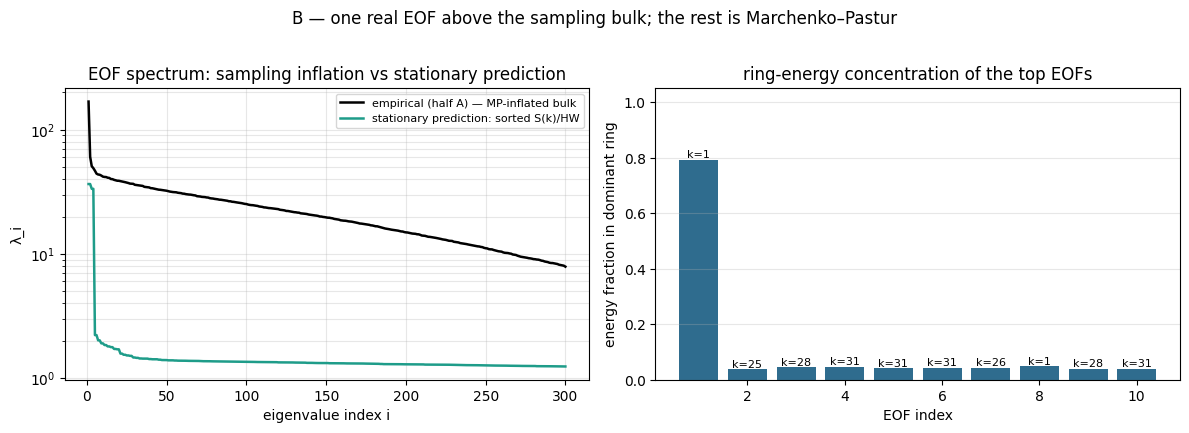

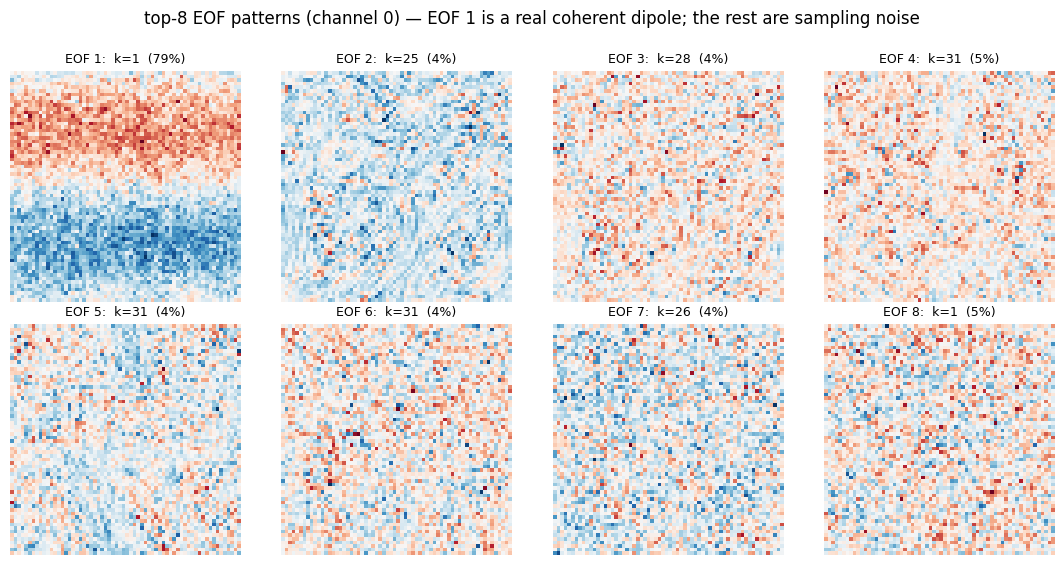

held-out/trained variance ratio λ_i^B/λ_i^A : [0.98 0.02 0.03 0.02 0.02 0.02 0.02 0.02 0.02 0.02]   (≪1 would mean overfit EOFs)
excess kurtosis of whitened EOF coords ã₁…ã₁₀: [ 0.64 -0.11  0.02  0.05  0.7  -0.36  0.07  1.14 -0.26 -0.39]  (0 = Gaussian)
rings 1–2: standardised Fourier-coord excess kurtosis +0.629   (0 = Gaussian)
rings 5–8: standardised Fourier-coord excess kurtosis +0.267   (0 = Gaussian)


rings 17–32: standardised Fourier-coord excess kurtosis +0.056   (0 = Gaussian)
λ₁ (trained) = 168  vs  largest stationary single-mode prediction 37  → EOF 1 is a coherent multi-mode k=1 pattern (mild spatial non-stationarity), alone carrying 2.2% of tr Σ̂


In [3]:
# ── B. split-half empirical EOFs ─────────────────────────────────────────────
rng  = np.random.default_rng(0)
perm = rng.permutation(N)
idxA, idxB = perm[:N // 2], perm[N // 2:]

muA = Z_raw[idxA].mean(axis=0, keepdims=True)                    # half-A per-lead mean field
Xa  = (Z_raw[idxA] - muA).reshape(-1, d).astype(np.float64)      # (n_A·L, d), leads pooled
_, sv, Vt = np.linalg.svd(Xa, full_matrices=False)
lam_eof = sv ** 2 / (Xa.shape[0] - 1)                            # eigenvalues of Σ̂_A

# stationary prediction: eigenvalues of Σ are the per-mode densities S(k)/(HW)
S_A      = (np.abs(np.fft.fft2((Z_raw[idxA] - muA), axes=(-2, -1))) ** 2).mean(axis=(0, 1))
lam_pred = np.sort(S_A.reshape(-1) / (H * W))[::-1]

# where does each top EOF live in ring space?
K_TOP = 10
Vh       = np.fft.fft2(Vt[:K_TOP].reshape(K_TOP, C, H, W), axes=(-2, -1))
ring_pow = np.stack([np.bincount(kr.ravel(), weights=vp.ravel(), minlength=B)
                     for vp in (np.abs(Vh) ** 2).sum(axis=1)])
ring_pow /= ring_pow.sum(axis=1, keepdims=True)
dom_ring, conc = ring_pow.argmax(axis=1), ring_pow.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ii = np.arange(1, 301)
axes[0].semilogy(ii, lam_eof[:300], 'k-', lw=1.8, label='empirical (half A) — MP-inflated bulk')
axes[0].semilogy(ii, lam_pred[:300], '-', color=cmap(0.55), lw=1.8,
                 label='stationary prediction: sorted S(k)/HW')
axes[0].set_xlabel('eigenvalue index i'); axes[0].set_ylabel('λ_i')
axes[0].set_title('EOF spectrum: sampling inflation vs stationary prediction')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, which='both')

axes[1].bar(np.arange(K_TOP) + 1, conc, color=cmap(0.35))
for i_, (dr, cc) in enumerate(zip(dom_ring, conc)):
    axes[1].annotate(f'k={dr}', (i_ + 1, cc), ha='center', va='bottom', fontsize=8)
axes[1].set_xlabel('EOF index'); axes[1].set_ylabel('energy fraction in dominant ring')
axes[1].set_ylim(0, 1.05); axes[1].set_title('ring-energy concentration of the top EOFs')
axes[1].grid(alpha=0.3, axis='y')
fig.suptitle('B — one real EOF above the sampling bulk; the rest is Marchenko–Pastur', y=1.02)
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for i_, ax in enumerate(axes.ravel()):
    ax.imshow(Vt[i_].reshape(C, H, W)[0], cmap='RdBu_r'); ax.axis('off')
    ax.set_title(f'EOF {i_ + 1}:  k={dom_ring[i_]}  ({conc[i_]:.0%})', fontsize=9)
fig.suptitle('top-8 EOF patterns (channel 0) — EOF 1 is a real coherent dipole; the rest are sampling noise', y=1.0)
fig.tight_layout(); plt.show()

# Gate 1 in the whitened basis — held-out coordinates ã_i = a_i/√λ_i should be N(0,1)
Ab    = (Z_raw[idxB] - muA).reshape(len(idxB), L, d).astype(np.float64) @ Vt[:K_TOP].T   # (n_B, L, K_TOP)
lam_B = (Ab ** 2).mean(axis=(0, 1))
print("held-out/trained variance ratio λ_i^B/λ_i^A :",
      np.array2string(lam_B / lam_eof[:K_TOP], precision=2), "  (≪1 would mean overfit EOFs)")
print("excess kurtosis of whitened EOF coords ã₁…ã₁₀:",
      np.array2string(stats.kurtosis(Ab.reshape(-1, K_TOP) / np.sqrt(lam_B), axis=0), precision=2),
      " (0 = Gaussian)")
for lo, hi in [(1, 2), (5, 8), (17, 32)]:
    msk = (kr >= lo) & (kr <= hi)
    zz  = Zh[..., msk] / np.sqrt(S_mode[:, msk] / 2)         # per-mode standardised Re/Im
    kk  = stats.kurtosis(np.concatenate([zz.real.ravel(), zz.imag.ravel()]))
    print(f"rings {lo}–{hi}: standardised Fourier-coord excess kurtosis {kk:+.3f}   (0 = Gaussian)")
print(f"λ₁ (trained) = {lam_eof[0]:.0f}  vs  largest stationary single-mode prediction "
      f"{lam_pred[0]:.0f}  → EOF 1 is a coherent multi-mode k=1 pattern (mild spatial "
      f"non-stationarity), alone carrying {lam_eof[0]/(d*var_field):.1%} of tr Σ̂")

## C. Per-mode temporal correlation $\rho_k(\Delta)$ — the separability test (doc §8)

The estimator, per ring $b$: from the FFT'd latents build per-sample **band Grams**
$G_b(n;\tau,\tau') = \tfrac{1}{HW\,d}\sum_{c,\,k\in b}\operatorname{Re}\big[\hat z^n_\tau(k)\,\overline{\hat z^n_{\tau'}(k)}\big]$,
normalise by the per-lead band variances, and collapse over the diagonals exactly as the scalar pipeline does — so SEs are comparable. Parseval guarantees $\sum_b G_b$ **equals the grid-space Gram exactly**: the ring decomposition is bookkeeping, not modelling (asserted below).

Then the test from §8: overlay $\bar\rho_k(\Delta)$ across rings.
- curves **collapse** → separable → the plain scalar $\alpha(t)$ of §3.6 is unbiased and the story ends;
- curves **fan out** (large scales slower) → non-separable → a single $\alpha(t)$ is a power-weighted blend and the right object is $\alpha(k, t)$.

Two side checks ride along: stationarity in $\tau$ *per scale* (the scalar version was checked in Step 2a), and a consistency overlay of the literal per-EOF $\rho_i(\Delta)$ (held-out projections from §B) against the ring curves they should match — recipe steps 4–5 done both ways.

Parseval check: max |Σ_b GB_b − G_grid| = 1.5e-08   → ring decomposition is exact bookkeeping


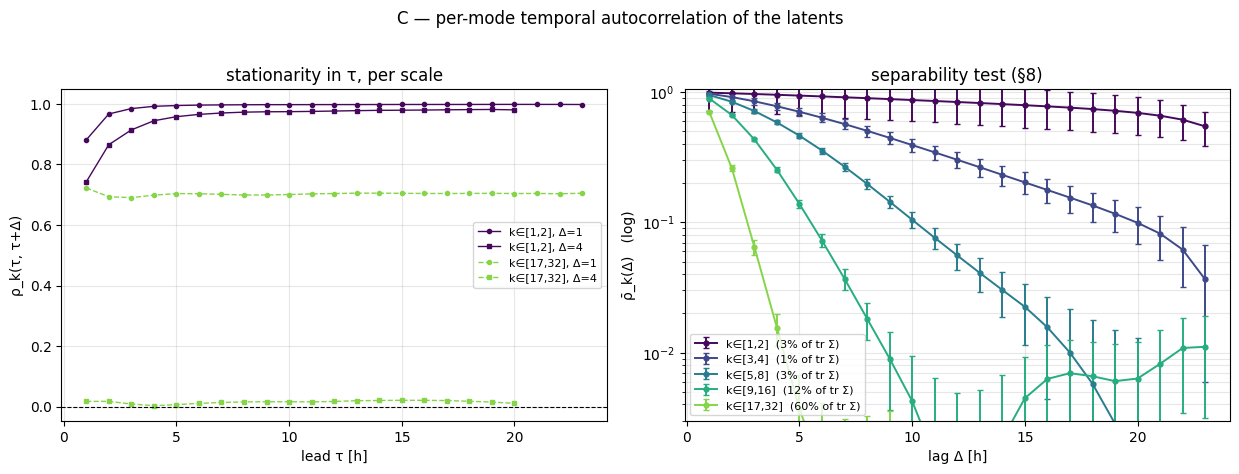

Δ= 1:  ρ̄(k∈[1,2]) − ρ̄(k∈[17,32]) = +0.287  =  2σ
Δ= 2:  ρ̄(k∈[1,2]) − ρ̄(k∈[17,32]) = +0.719  =  5σ
Δ= 4:  ρ̄(k∈[1,2]) − ρ̄(k∈[17,32]) = +0.938  =  7σ
Δ= 8:  ρ̄(k∈[1,2]) − ρ̄(k∈[17,32]) = +0.897  =  7σ


In [4]:
# ── C. per-ring lead×lead Grams (Parseval-exact bookkeeping) ─────────────────
def band_grams(Zc_in):
    '''Per-lead-centered (n, L, C, H, W) → GB (B, n, L, L) with Σ_b GB_b = grid Gram/d exactly.'''
    n = Zc_in.shape[0]
    Zh_ = np.empty(Zc_in.shape, np.complex64)
    for i0 in range(0, n, 64):                                   # chunked FFT: bounded memory
        Zh_[i0:i0 + 64] = np.fft.fft2(Zc_in[i0:i0 + 64], axes=(-2, -1))
    out = np.empty((B, n, L, L), np.float64)
    for b in range(B):
        Zb = Zh_[..., kr == b].astype(np.complex128).reshape(n, L, -1)   # channels+modes flat
        out[b] = np.einsum('nlm,npm->nlp', Zb, Zb.conj()).real
    return out / ((H * W) * d)

def band_curves(GB_in):
    '''GB (B, n, L, L) → ρ̄_b(Δ), SE_b(Δ), per-lead band variances v_b(τ), normalised Grams.'''
    v  = np.einsum('bnll->bnl', GB_in).mean(axis=1)              # (B, L)
    Gn = GB_in / np.sqrt(v[:, None, :, None] * v[:, None, None, :])
    rho, se = np.empty((GB_in.shape[0], L - 1)), np.empty((GB_in.shape[0], L - 1))
    for b in range(GB_in.shape[0]):
        rho[b], se[b] = collapse_by_lag(Gn[b])
    return rho, se, v, Gn

GB = band_grams(Zc)
G_grid = np.einsum('nlx,nmx->nlm', Zc.reshape(N, L, -1).astype(np.float64),
                                   Zc.reshape(N, L, -1).astype(np.float64)) / d
err = np.abs(GB.sum(axis=0) - G_grid).max()
print(f"Parseval check: max |Σ_b GB_b − G_grid| = {err:.1e}   → ring decomposition is exact bookkeeping")
assert err < 1e-6

rho_b, se_b, v_b, Gn_b = band_curves(GB)

# ring groups for readable curves (fits in §E stay per-ring); labels carry the trace share
GROUPS = [(1, 2), (3, 4), (5, 8), (9, 16), (17, 32)]
def group_curves(GB_in):
    out = {}
    for lo, hi in GROUPS:
        Gg = GB_in[lo:hi + 1].sum(axis=0)
        vg = np.einsum('nll->nl', Gg).mean(axis=0)
        out[(lo, hi)] = collapse_by_lag(Gg / np.sqrt(vg[None, :, None] * vg[None, None, :]))
    return out
grp   = group_curves(GB)
gcol  = {g: cmap(x) for g, x in zip(GROUPS, np.linspace(0.02, 0.82, len(GROUPS)))}
glab  = {g: f'k∈[{g[0]},{g[1]}]  ({trace_share[g[0]:g[1]+1].sum():.0%} of tr Σ)' for g in GROUPS}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for g, ls in [((1, 2), '-'), ((17, 32), '--')]:
    Gg = GB[g[0]:g[1] + 1].sum(axis=0)
    vg = np.einsum('nll->nl', Gg).mean(axis=0)
    Rg = (Gg / np.sqrt(vg[None, :, None] * vg[None, None, :])).mean(axis=0)
    for D, mk in [(1, 'o'), (4, 's')]:
        axes[0].plot(leads[:L - D], np.diagonal(Rg, offset=D), mk, ls=ls, ms=3, lw=1,
                     color=gcol[g], label=f'k∈[{g[0]},{g[1]}], Δ={D}')
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_xlabel('lead τ [h]'); axes[0].set_ylabel('ρ_k(τ, τ+Δ)')
axes[0].set_title('stationarity in τ, per scale'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for g in GROUPS:
    (r_, s_) = grp[g]
    m_ = r_ > 0
    axes[1].errorbar(deltas[m_], r_[m_], yerr=2 * s_[m_], fmt='o-', ms=3.5, lw=1.4,
                     capsize=2, color=gcol[g], label=glab[g])
axes[1].set_yscale('log'); axes[1].set_ylim(3e-3, 1.05)
axes[1].set_xlabel('lag Δ [h]'); axes[1].set_ylabel('ρ̄_k(Δ)   (log)')
axes[1].set_title('separability test (§8)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, which='both')
fig.suptitle('C — per-mode temporal autocorrelation of the latents', y=1.02)
fig.tight_layout(); plt.show()

for D in [1, 2, 4, 8]:
    i = D - 1
    gap = grp[GROUPS[0]][0][i] - grp[GROUPS[-1]][0][i]
    sig = np.hypot(grp[GROUPS[0]][1][i], grp[GROUPS[-1]][1][i])
    print(f"Δ={D:>2}:  ρ̄(k∈[1,2]) − ρ̄(k∈[17,32]) = {gap:+.3f}  =  {gap / sig:.0f}σ")

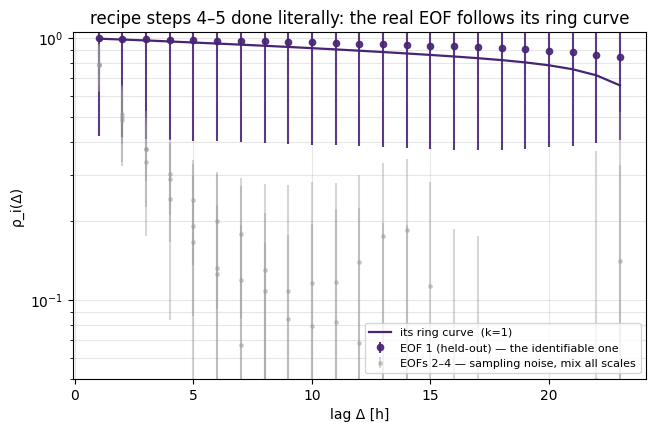

In [5]:
# ── C (cont.) the one real EOF, checked literally against its ring curve ─────
fig, ax = plt.subplots(figsize=(7.4, 4.5))
for i_ in range(4):
    a  = Ab[..., i_]                                             # held-out projections (n_B, L)
    Ga = np.einsum('nl,nm->nlm', a, a)
    va = np.einsum('nll->nl', Ga).mean(axis=0)
    rr, ss = collapse_by_lag(Ga / np.sqrt(va[None, :, None] * va[None, None, :]))
    real_eof = (i_ == 0)
    col = cmap(0.1) if real_eof else '0.6'
    m_  = rr > 0
    ax.errorbar(deltas[m_], rr[m_], yerr=2 * ss[m_], fmt='o', ms=4.5 if real_eof else 2.5,
                color=col, alpha=0.9 if real_eof else 0.4,
                label=('EOF 1 (held-out) — the identifiable one' if real_eof else
                       ('EOFs 2–4 — sampling noise, mix all scales' if i_ == 1 else None)))
    if real_eof:
        mb = rho_b[dom_ring[0]] > 0
        ax.plot(deltas[mb], rho_b[dom_ring[0]][mb], '-', lw=1.6, color=col,
                label=f'its ring curve  (k={dom_ring[0]})')
ax.set_yscale('log'); ax.set_ylim(5e-2, 1.05)
ax.set_xlabel('lag Δ [h]'); ax.set_ylabel('ρ_i(Δ)')
ax.set_title('recipe steps 4–5 done literally: the real EOF follows its ring curve')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
plt.show()

**Reading C.**

- **Stationarity per scale**: the high-$k$ curves are flat in $\tau$ at every lag. $k\in[1,2]$ rises over the first $\sim$3 leads (0.88 → 0.99 at $\Delta$=1) before flattening — the same early-lead anomaly as §A's $\lambda_{\tau=1}(k{=}1) = 0.44\,\lambda(k{=}1)$: the coherent large-scale error component takes a few leads to build up. Beyond $\tau \approx 4$ the lag-collapse is legitimate everywhere; for $k \le 2$ it mildly mixes the first leads in (conservative).
- **Separability is rejected, decisively**: the gap between $k\in[1,2]$ and $k\in[17,32]$ is 5σ at $\Delta$=2 and 7σ from $\Delta$=4 on. At $\Delta$=23 the largest scales still hold $\bar\rho \approx 0.55$ while $k\in[17,32]$ is statistically dead by $\Delta \approx 4$. In §8's terms the curves do **not** collapse ⟹ $C(t) \neq \alpha(t)\Sigma$ ⟹ a single scalar $\alpha(t)$ is not the right object; $\alpha(k,t)$ is.
- A detail that §E will pick up: at $\Delta$=1 *every* scale is strongly correlated (0.99 at $k\in[1,2]$, 0.70 even at $k\in[17,32]$) — mild separation compared to what follows (by $\Delta$=4 the ratio is two orders of magnitude). The violent divergence starts at $\Delta$=2, not 1.
- **EOF cross-check**: the one identifiable EOF (§B) rides its ring curve within its (wide, $n$=32) error bars — the literal recipe (steps 4–5 per EOF) and the ring proxy agree where both are estimable. The gray sampling-noise EOFs mix all scales and match no single ring curve, as expected.

## D. The scalar $\hat\alpha(t)$ is the power-weighted blend — OLS vs GLS

The identity $\hat\alpha(\Delta) = \sum_k \hat w_k\,\bar\rho_k(\Delta)$ with static weights $\hat w_k = \overline{v}_k / \sum \overline{v}$ (ring share of $\operatorname{tr}\hat\Sigma$) should reproduce the grid-space scalar curve from Step 1/2 to within its SE — the residual is only the mild lead-dependence of the band variances.

The doc's §3 adds the efficiency angle: the **GLS / whitened** estimator $\hat\alpha_{\rm GLS} = \operatorname{tr}(\Sigma^{-1/2} C \Sigma^{-1/2})/d$ weights every *mode* equally, i.e. ring weight $\propto m_k$ (mode count), which is dominated by the many high-$k$ modes — whereas OLS weights by *power*, dominated by the few low-$k$ modes. In the separable case the two coincide exactly; their gap is therefore a second, purely scalar separability statistic. For reference, the correlation the current sampler imposes (`get_latents`, AR(1) with coefficient $\sqrt\alpha$, $\alpha=0.5$): $\rho(\Delta) = 0.5^{\Delta/2}$ — a *single* rate for every spatial scale.

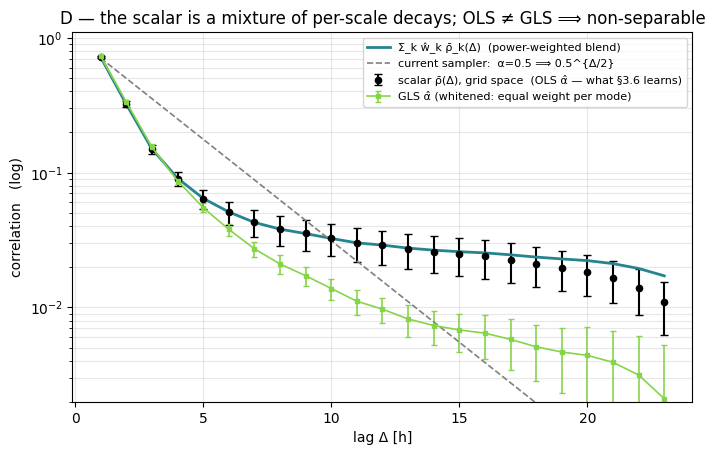

blend identity:  max |Σŵρ̄_k − ρ̄_grid| = 0.0062   (2·max SE = 0.0160)
Δ=1:  OLS 0.718  vs  GLS 0.726   →  gap -1σ
Δ=4:  OLS 0.090  vs  GLS 0.087   →  gap +1σ
Δ=8:  OLS 0.038  vs  GLS 0.021   →  gap +3σ
separable ⟹ OLS = GLS exactly (§3); a many-σ gap is a scalar-level separability rejection.


In [6]:
# ── D. blend identity + OLS-vs-GLS ───────────────────────────────────────────
w_hat = v_b.mean(axis=1) / v_b.mean(axis=1).sum()        # static ring weights ŵ_k  (Σ_k ŵ_k = 1)
blend = w_hat @ rho_b                                    # Σ_k ŵ_k ρ̄_k(Δ)

Gn_gls = np.einsum('b,bnlm->nlm', m_b / m_b.sum(), Gn_b) # equal weight per MODE = whitened trace
rho_gls, se_gls = collapse_by_lag(Gn_gls)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(deltas, rho_grid, yerr=2 * se_grid, fmt='ko', ms=4.5, capsize=3,
            label='scalar ρ̄(Δ), grid space  (OLS α̂ — what §3.6 learns)')
ax.plot(deltas, blend, '-', lw=2, color=cmap(0.45), label='Σ_k ŵ_k ρ̄_k(Δ)  (power-weighted blend)')
mg = rho_gls > 0
ax.errorbar(deltas[mg], rho_gls[mg], yerr=2 * se_gls[mg], fmt='s-', ms=3, lw=1.2, capsize=2,
            color=cmap(0.82), label='GLS α̂ (whitened: equal weight per mode)')
ax.plot(deltas, 0.5 ** (deltas / 2), '--', color='gray', lw=1.2,
        label='current sampler:  α=0.5 ⟹ 0.5^{Δ/2}')
ax.set_yscale('log'); ax.set_ylim(2e-3, 1.1)
ax.set_xlabel('lag Δ [h]'); ax.set_ylabel('correlation   (log)')
ax.set_title('D — the scalar is a mixture of per-scale decays; OLS ≠ GLS ⟹ non-separable')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
plt.show()

print(f"blend identity:  max |Σŵρ̄_k − ρ̄_grid| = {np.abs(blend - rho_grid).max():.4f}"
      f"   (2·max SE = {2 * se_grid.max():.4f})")
for D in [1, 4, 8]:
    i = D - 1
    z = (rho_grid[i] - rho_gls[i]) / np.hypot(se_grid[i], se_gls[i])
    print(f"Δ={D}:  OLS {rho_grid[i]:.3f}  vs  GLS {rho_gls[i]:.3f}   →  gap {z:+.0f}σ")
print("separable ⟹ OLS = GLS exactly (§3); a many-σ gap is a scalar-level separability rejection.")

**Reading D.**

- **The blend identity holds**: $\max_\Delta |\sum_k \hat w_k \bar\rho_k - \bar\rho_{\rm grid}| = 0.006 < 2\,\mathrm{SE} = 0.016$. The Step-1/2 scalar curve **is** the power-weighted mixture of per-scale decays — the concave semilog shape that defeated both OU and squared-exponential fits in `empirical_correlation` Step 2b is now mechanically explained. Nothing about $\Sigma \neq I$ corrupts the scalar estimator; it just averages.
- **Where the weights actually sit** (a genuine surprise relative to the doc's §4 intuition): the *latent* field is near-white in total power — $\operatorname{tr}\hat\Sigma$ is dominated by the many high-$k$ modes (50% above $k$=26; $k\le8$ holds only 6%). The physical SQG field's energy lives at large scales; the latent's does not, because the latent is noise-like by construction and its red excess is confined to a few large-scale modes. Consequently OLS ≈ GLS at short lags (−1σ at $\Delta$=1), and the separability violation surfaces in the **tail**: +3σ at $\Delta$=8, a factor ≈ 2 beyond $\Delta \approx 12$, where only the slow low-$k$ modes still carry correlation. The scalar's heavy tail *is* low-$k$ memory, carried by a few percent of $\operatorname{tr}\hat\Sigma$.
- **The α=0.5 sampler in this light**: its lag-1 value $0.5^{1/2} = 0.707$ lands almost on the empirical $\bar\rho(1) = 0.718$ — aggregate lag-1 calibration by coincidence (the trace is high-$k$ dominated) — but a single rate then over-correlates $\Delta$ = 2–9 and under-correlates $\Delta \gtrsim 10$, and is wrong per scale even at $\Delta$=1 (0.99 at $k\le2$ vs 0.70 at $k\ge17$). No scalar α fixes this; §E's $\alpha(k,t)$ does.
- §3's efficiency statement is confirmed in the flesh: whitening (GLS) moves the estimate by at most a few σ — $\Sigma \neq I$ costs estimator variance, never bias.

## E. Scale-resolved $\alpha(k, \Delta)$: per-ring fits and the SDE coefficients (doc §6)

Per ring, weighted least squares on $\log\bar\rho_k(\Delta) = \log g_k - r_k\,\Delta$ over the leading run of lags above the noise floor ($\bar\rho > 3\cdot$SE):

- **slope** → decay rate $r_k$; under the doc's marginal-preserving OU family $c_k^2 = -2\,\frac{d}{dt}\log\rho_k = 2 r_k$, *provided* the semilog line is straight;
- **intercept** $g_k$: per-lead-independent inversion noise would give a classical *nugget* $g<1$ (uniform multiplicative attenuation). $g_k > 1$ instead means a **short-lag shoulder** — $\bar\rho_k(1)$ sits *above* the exponential that fits $\Delta \ge 2$, i.e. the per-mode kernel is smoother than OU at short lags (finite inertia, Matérn-like) — made explicit by the model-free check below;
- **model-free** $\tilde c^2(\Delta) = -2\,\Delta_{\rm fd}\log\bar\rho_k$: constant ⟹ time-homogeneous OU; rising-to-plateau ⟹ the shoulder. A uniform multiplicative attenuation cancels *exactly* in $\tilde c^2$, so this diagnostic is immune to inversion noise (and §G varies the inversion fidelity as a direct test);
- **§6 consistency**: $c_k^2 \ge 0$ ⟺ $\bar\rho_k$ non-increasing — significant increases would flag the per-mode Markov family as misspecified outright.

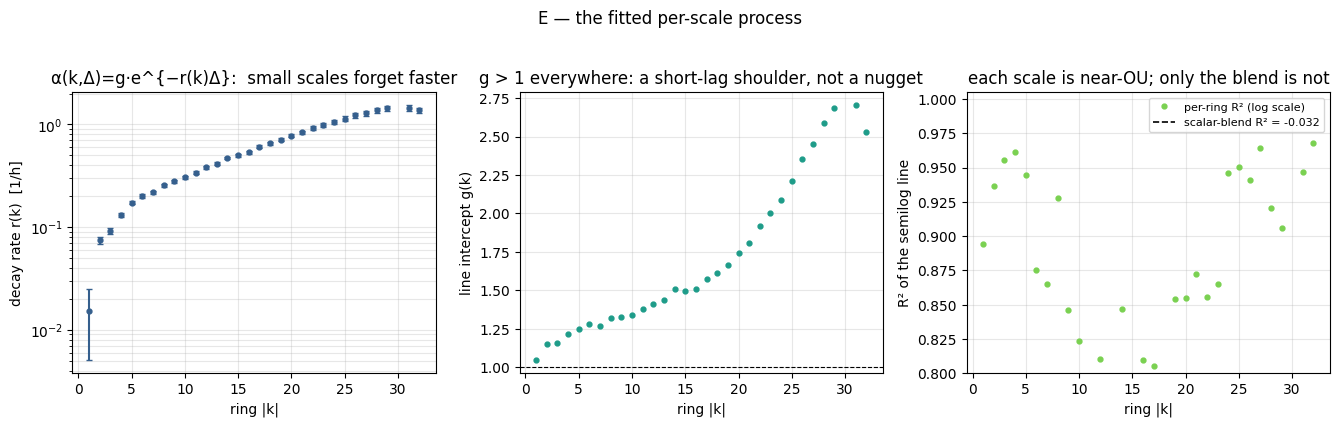

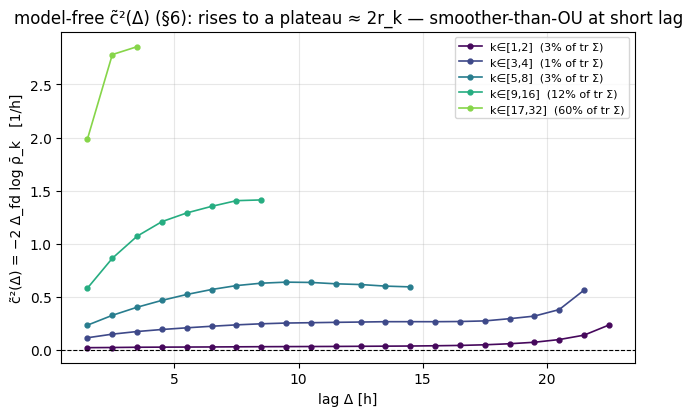

rings with g(k) > 1: 31/31 — the shoulder is systematic
§6 consistency (ρ̄_k non-increasing ⟺ c_k² ≥ 0): no significant increases in any fitted ring ✓

   k    r(k) [1/h]      τ_dec = 1/r [h]    c_k² = 2r(k)     g(k)     R²      lags used
   1   0.015 ± 0.010        66.3          0.030         1.043    0.894     23
   2   0.075 ± 0.006        13.3          0.150         1.153    0.937     23
   4   0.131 ± 0.005         7.6          0.262         1.213    0.961     21
   8   0.255 ± 0.008         3.9          0.510         1.320    0.928     14
  16   0.535 ± 0.015         1.9          1.069         1.507    0.809     5
  32   1.375 ± 0.086         0.7          2.750         2.533    0.968     3


In [7]:
# ── E. per-ring WLS fits on the semilog curves ───────────────────────────────
def fit_ring(rho, se):
    '''WLS line on log ρ̄(Δ) over the leading run with ρ̄ > max(3·SE, 0).'''
    valid = (rho > 3 * se) & (rho > 0)
    nv = int(np.argmin(valid)) if not valid.all() else valid.size
    if nv == 0:
        return dict(r=np.nan, se_r=np.nan, g=np.nan, r2=np.nan, n=0)
    if nv == 1:
        return dict(r=-np.log(rho[0]), se_r=se[0] / rho[0], g=np.nan, r2=np.nan, n=1)
    Dv, y, sig = deltas[:nv], np.log(rho[:nv]), se[:nv] / rho[:nv]
    coef, cov = np.polyfit(Dv, y, 1, w=1 / sig, cov='unscaled')
    r2 = 1 - ((y - np.polyval(coef, Dv)) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return dict(r=-coef[0], se_r=np.sqrt(cov[0, 0]), g=float(np.exp(coef[1])), r2=r2, n=nv)

fits  = [fit_ring(rho_b[b], se_b[b]) for b in range(B)]
r_k   = np.array([f['r']    for f in fits])
se_rk = np.array([f['se_r'] for f in fits])
g_k   = np.array([f['g']    for f in fits])
r2_k  = np.array([f['r2']   for f in fits])
n_k   = np.array([f['n']    for f in fits])
ok    = np.array([b for b in range(1, K_ISO + 1) if n_k[b] >= 3])

fit_scalar = fit_ring(rho_grid, se_grid)          # the blend fitted the same way, for contrast

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.1))
axes[0].errorbar(ok, r_k[ok], yerr=2 * se_rk[ok], fmt='o', ms=3.5, capsize=2, color=cmap(0.3))
axes[0].set_yscale('log')
axes[0].set_xlabel('ring |k|'); axes[0].set_ylabel('decay rate r(k)  [1/h]')
axes[0].set_title('α(k,Δ)=g·e^{−r(k)Δ}:  small scales forget faster')
axes[0].grid(alpha=0.3, which='both')

axes[1].plot(ok, g_k[ok], 'o', ms=3.5, color=cmap(0.55))
axes[1].axhline(1, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('ring |k|'); axes[1].set_ylabel('line intercept g(k)')
axes[1].set_title('g > 1 everywhere: a short-lag shoulder, not a nugget')
axes[1].grid(alpha=0.3)

axes[2].plot(ok, r2_k[ok], 'o', ms=3.5, color=cmap(0.8), label='per-ring R² (log scale)')
axes[2].axhline(fit_scalar['r2'], color='k', lw=1.2, ls='--',
                label=f"scalar-blend R² = {fit_scalar['r2']:.3f}")
axes[2].set_xlabel('ring |k|'); axes[2].set_ylabel('R² of the semilog line')
axes[2].set_ylim(0.8, 1.005); axes[2].legend(fontsize=8)
axes[2].set_title('each scale is near-OU; only the blend is not')
axes[2].grid(alpha=0.3)
fig.suptitle('E — the fitted per-scale process', y=1.03)
fig.tight_layout(); plt.show()

# model-free c²(Δ) per ring group — constant ⟹ time-homogeneous OU per scale
fig, ax = plt.subplots(figsize=(7.4, 4.3))
for g in GROUPS:
    r_, s_ = grp[g]
    valid  = (r_ > 3 * s_) & (r_ > 0)
    nv     = int(np.argmin(valid)) if not valid.all() else valid.size
    if nv >= 2:
        c2 = -2 * np.diff(np.log(r_[:nv]))
        ax.plot(deltas[:nv - 1] + 0.5, c2, 'o-', ms=3.5, lw=1.2, color=gcol[g], label=glab[g])
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('lag Δ [h]'); ax.set_ylabel('c̃²(Δ) = −2 Δ_fd log ρ̄_k   [1/h]')
ax.set_title('model-free c̃²(Δ) (§6): rises to a plateau ≈ 2r_k — smoother-than-OU at short lag')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

viol = []
for b in range(1, K_ISO + 1):
    r_, s_ = rho_b[b], se_b[b]
    valid  = (r_ > 3 * s_) & (r_ > 0)
    nv     = int(np.argmin(valid)) if not valid.all() else valid.size
    if nv >= 2:
        inc = np.diff(r_[:nv]) > 2 * np.hypot(s_[:nv - 1], s_[1:nv])
        if inc.any():
            viol.append((b, list(deltas[:nv - 1][inc])))
print(f"rings with g(k) > 1: {(g_k[ok] > 1).sum()}/{ok.size} — the shoulder is systematic")
print("§6 consistency (ρ̄_k non-increasing ⟺ c_k² ≥ 0): "
      + (f"violations at rings {viol}" if viol else "no significant increases in any fitted ring ✓"))
print("\n   k    r(k) [1/h]      τ_dec = 1/r [h]    c_k² = 2r(k)     g(k)     R²      lags used")
for b in [1, 2, 4, 8, 16, 32]:
    f = fits[b]
    if np.isfinite(f['r']):
        print(f"  {b:>2}   {f['r']:.3f} ± {2*f['se_r']:.3f}     {1/f['r']:7.1f}          "
              f"{2*f['r']:.3f}         {f['g']:.3f}    {(f['r2'] if np.isfinite(f['r2']) else np.nan):.3f}"
              f"     {f['n']}")

**Reading E.**

- **The scale-resolved law**: $r(k)$ rises monotonically from 0.015 h⁻¹ at $k$=1 ($\tau_{\rm dec} \approx 66$ h — longer than the whole 24 h window, hence the barely-decaying purple curve in C) to $\approx$1.4 h⁻¹ at $k$=32 ($\tau_{\rm dec} \approx 0.7$ h). Equivalently $c_k^2 = 2r_k$ spans 0.03 → 2.8. *Large eddies remember, small eddies forget* — now with numbers.
- **Per scale near-OU; blended, hopeless**: per-ring semilog R² = 0.81–0.97 across all 31 fitted rings, against R² = **−0.03** for the same fit on the scalar curve (worse than a constant). One number each for "the OU family is a good per-mode model" and "no scalar exponential can represent the blend".
- **§6 consistency passes**: no significant $\bar\rho_k$ increase in any fitted ring ⟹ $c_k^2 \ge 0$ everywhere ⟹ a per-mode diffusion representation exists.
- **The systematic residual is a short-lag shoulder**: all 31 intercepts have $g_k > 1$, growing with $k$ (1.04 → 2.7), and the model-free $\tilde c^2(\Delta)$ rises to its plateau $\approx 2r_k$ over the first few hours instead of being flat. Both say the same thing: $\bar\rho_k(1)$ sits above the exponential that fits $\Delta \ge 2$ — each mode's kernel is *smoother than OU at short lag* (finite inertia, Matérn-like), increasingly so at high $k$. A uniform multiplicative attenuation cancels exactly in both the slope and $\tilde c^2$, so per-lead-independent inversion noise cannot produce this (and §G confirms invariance to inversion fidelity). A time-varying $c_i(t)$ could fit any single monotone curve but would break the observed stationarity in $\tau$ (§C left panel) — the honest reading is a **stationary, slightly non-Markov kernel per mode**, the extension §6 itself anticipates.
- Practical summary: $\alpha(k,\Delta) \approx g_k\,e^{-r_k \Delta}$ for $\Delta \ge 1$ with the table's $r(k)$; the $\Delta \in (0,1)$ shoulder is a kernel-family question (hourly data cannot resolve it), not an estimation problem.

## F. Closing the loop: simulate the learned process (doc §5, recipe step 8-lite)

Two simulations, both built on **independent whitened Fourier modes** re-coloured by the empirical per-mode power $\hat S(k)$ — so both preserve the grid-space marginal $\mathcal N(0, \hat\Sigma)$ at **every** lead *by construction*. This is §5's argument realised with rings in place of literal EOFs: "independent coordinates" holds per whitened mode, not per pixel.

1. **homogeneous OU(k)** — the doc's §3.5 family with the fitted rates: $\hat a_{\tau+1} = \varphi_k\,\hat a_\tau + \sqrt{1-\varphi_k^2}\,\hat\xi$, $\varphi_k = e^{-r(|k|)}$;
2. **measured-kernel process** — kernel-agnostic: per ring, a stationary Gaussian process whose correlation sequence *is* the measured $\alpha(k,\Delta)$ (raw $\bar\rho_k$ over its trusted lags, fitted-exponential continuation beyond, PSD-projected, unit diagonal restored). This is "the learned $\alpha(k,t)$" with no parametric family imposed; the size of the PSD projection is printed — a large one would mean the measured kernels are not jointly consistent.

(The intercepts $g_k$ are *not* injected into either simulation — they are a property of the kernel shape, and sim 2 carries that shape automatically through the raw $\bar\rho_k$ values.)

Checks: **(i)** per-lead ring spectra sit on the target $\lambda(k)$ — marginal preservation; **(ii)** the grid-space scalar $\bar\rho(\Delta)$ of each simulation vs the empirical curve — OU(k) should capture $\Delta \gtrsim 4$ but undershoot the 1–3 h shoulder (§E), while the measured-kernel process should reproduce the whole concave curve, *including* the tail that the current $\alpha=0.5$ sampler misses; **(iii)** visually, large scales persist while small scales churn.

PSD projection of the measured kernels: worst negative eigenvalue 0.0329   (tiny ⟹ the measured α(k,Δ) is a consistent stationary correlation)


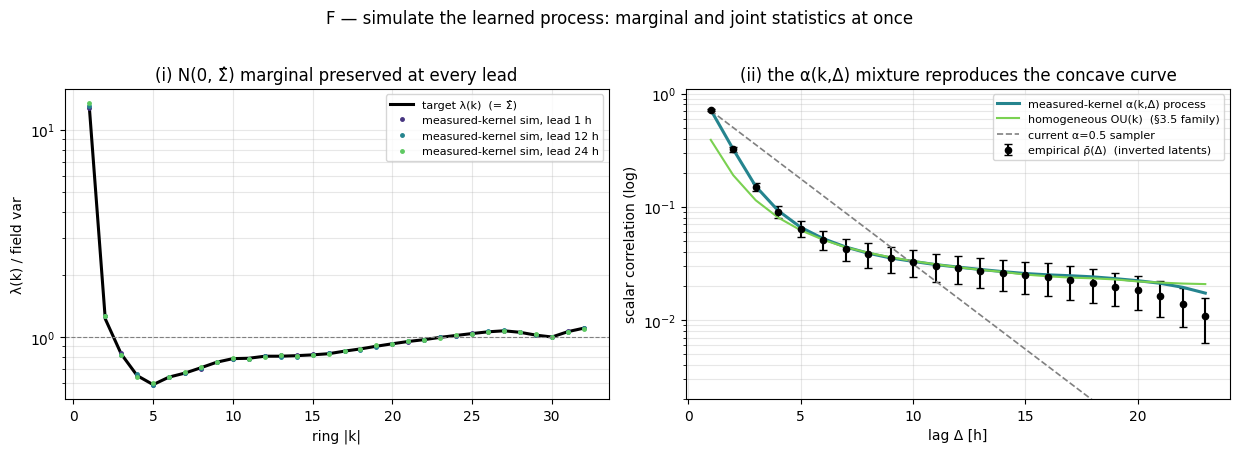

per-lead field std of the measured-kernel sim: [0.9640, 0.9659]   (marginal preserved)
OU(k)           : at Δ=1  sim 0.390 vs emp 0.718;   max |ρ̄_sim − ρ̄_emp| over Δ≤12 = 0.328   (2·max SE = 0.016)
measured-kernel : at Δ=1  sim 0.718 vs emp 0.718;   max |ρ̄_sim − ρ̄_emp| over Δ≤12 = 0.002   (2·max SE = 0.016)


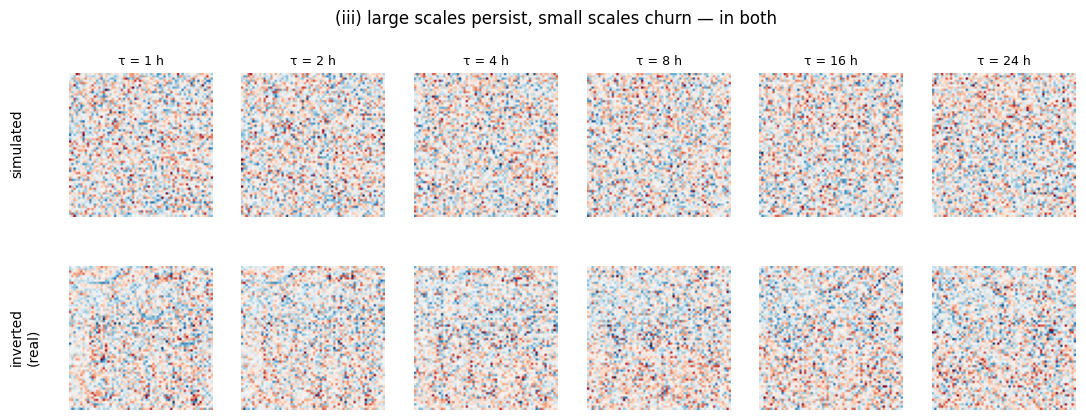

In [8]:
# ── F. simulate the learned per-mode process, two ways ───────────────────────
from scipy.linalg import toeplitz

r_full = r_k.copy()
good   = np.array([b for b in range(1, K_ISO + 1) if np.isfinite(r_k[b])])
for b in range(B):                                # DC / corners / unfittable → nearest fitted ring
    if not (np.isfinite(r_full[b]) and 1 <= b <= K_ISO):
        r_full[b] = r_k[good[np.argmin(np.abs(good - b))]]

amp = np.sqrt(S_mode / (H * W)).astype(np.float32)            # colouring: unit white → power Ŝ
M, rng_sim = 256, np.random.default_rng(1)
shaped = lambda: (np.fft.fft2(rng_sim.standard_normal((M, C, H, W)).astype(np.float32),
                              axes=(-2, -1)) * amp).astype(np.complex64)

# ── sim 1: homogeneous OU(k) — the §3.5 family ──
phi  = np.exp(-r_full[kr])[None, None].astype(np.float32)
E_ou = np.empty((M, L, C, H, W), np.float32)
ah   = shaped()                                               # stationary start (lead 1)
E_ou[:, 0] = np.fft.ifft2(ah, axes=(-2, -1)).real
for j in range(1, L):
    ah = phi * ah + np.sqrt(1 - phi ** 2) * shaped()
    E_ou[:, j] = np.fft.ifft2(ah, axes=(-2, -1)).real
Gn_ou, _  = gram_corr(E_ou - E_ou.mean(axis=0, keepdims=True))
rho_ou, _ = collapse_by_lag(Gn_ou)
del E_ou, ah, Gn_ou

# ── sim 2: measured-kernel stationary process — kernel-agnostic α(k, Δ) ──
def ring_kernel(b):
    '''α(k, Δ), Δ = 0…L−1: raw ρ̄_k over trusted lags, exp continuation, monotone.'''
    rho, se = rho_b[b], se_b[b]
    valid = (rho > 3 * se) & (rho > 0)
    nv  = int(np.argmin(valid)) if not valid.all() else valid.size
    seq = np.empty(L); seq[0] = 1.0
    seq[1:nv + 1] = rho[:nv]
    for j in range(nv + 1, L):
        seq[j] = seq[j - 1] * np.exp(-r_full[b])
    return np.minimum.accumulate(seq)

F_stack, worst_neg = np.empty((B, L, L), np.float32), 0.0
for b in range(B):
    R      = toeplitz(ring_kernel(b))
    ev, U  = np.linalg.eigh(R)
    worst_neg = max(worst_neg, -ev.min())
    Rp     = (U * np.maximum(ev, 1e-9)) @ U.T                 # PSD projection
    dg     = np.sqrt(np.diag(Rp)); Rp /= np.outer(dg, dg)     # unit diagonal ⟹ marginal exact
    ev2, U2 = np.linalg.eigh(Rp)
    F_stack[b] = U2 * np.sqrt(np.maximum(ev2, 0))
print(f"PSD projection of the measured kernels: worst negative eigenvalue {worst_neg:.4f}"
      f"   (tiny ⟹ the measured α(k,Δ) is a consistent stationary correlation)")

FK = np.ascontiguousarray(F_stack[kr].transpose(2, 3, 0, 1))  # (L, L, H, W) per-mode factor
Xi = [shaped() for _ in range(L)]                             # L independent coloured noises
E_ker = np.empty((M, L, C, H, W), np.float32)
for t in range(L):
    acc = np.zeros((M, C, H, W), np.complex64)
    for j in range(L):
        if np.abs(FK[t, j]).max() > 1e-7:
            acc += FK[t, j][None, None] * Xi[j]
    E_ker[:, t] = np.fft.ifft2(acc, axes=(-2, -1)).real
del Xi, acc, FK
Gn_ker, _  = gram_corr(E_ker - E_ker.mean(axis=0, keepdims=True))
rho_ker, _ = collapse_by_lag(Gn_ker)

# ── checks ──
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].semilogy(ks, lam_pool[1:K_ISO + 1] / var_field, 'k-', lw=2.2, label='target λ(k)  (= Σ̂)')
for i, t in enumerate([1, 12, 24]):
    lam_s = ring_density((np.abs(np.fft.fft2(E_ker[:, t - 1], axes=(-2, -1))) ** 2).mean(axis=0))
    axes[0].semilogy(ks, lam_s[1:K_ISO + 1] / var_field, 'o', ms=2.5,
                     color=cmap(0.15 + 0.3 * i), label=f'measured-kernel sim, lead {t} h')
axes[0].axhline(1, color='gray', lw=0.8, ls='--')
axes[0].set_xlabel('ring |k|'); axes[0].set_ylabel('λ(k) / field var')
axes[0].set_title('(i) N(0, Σ̂) marginal preserved at every lead')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, which='both')

axes[1].errorbar(deltas, rho_grid, yerr=2 * se_grid, fmt='ko', ms=4.5, capsize=3,
                 label='empirical ρ̄(Δ)  (inverted latents)')
axes[1].plot(deltas, rho_ker, '-',  lw=2.2, color=cmap(0.45), label='measured-kernel α(k,Δ) process')
axes[1].plot(deltas, rho_ou,  '-',  lw=1.5, color=cmap(0.8),  label='homogeneous OU(k)  (§3.5 family)')
axes[1].plot(deltas, 0.5 ** (deltas / 2), '--', color='gray', lw=1.2, label='current α=0.5 sampler')
axes[1].set_yscale('log'); axes[1].set_ylim(2e-3, 1.1)
axes[1].set_xlabel('lag Δ [h]'); axes[1].set_ylabel('scalar correlation (log)')
axes[1].set_title('(ii) the α(k,Δ) mixture reproduces the concave curve')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, which='both')
fig.suptitle('F — simulate the learned process: marginal and joint statistics at once', y=1.02)
fig.tight_layout(); plt.show()

print(f"per-lead field std of the measured-kernel sim: [{E_ker.std(axis=(0,2,3,4)).min():.4f}, "
      f"{E_ker.std(axis=(0,2,3,4)).max():.4f}]   (marginal preserved)")
for name, rs in [('OU(k)', rho_ou), ('measured-kernel', rho_ker)]:
    print(f"{name:16s}: at Δ=1  sim {rs[0]:.3f} vs emp {rho_grid[0]:.3f};   "
          f"max |ρ̄_sim − ρ̄_emp| over Δ≤12 = {np.abs(rs[:12] - rho_grid[:12]).max():.3f}"
          f"   (2·max SE = {2 * se_grid[:12].max():.3f})")

# (iii) visual: one simulated window vs one real inverted window
show = [1, 2, 4, 8, 16, 24]
fig, axes = plt.subplots(2, len(show), figsize=(13, 4.6))
for j, t in enumerate(show):
    axes[0, j].imshow(E_ker[0, t - 1, 0], cmap='RdBu_r', vmin=-3, vmax=3)
    axes[1, j].imshow(Zc[0, t - 1, 0],    cmap='RdBu_r', vmin=-3, vmax=3)
    axes[0, j].set_title(f'τ = {t} h', fontsize=9)
    for ax in (axes[0, j], axes[1, j]): ax.axis('off')
fig.text(0.08, 0.71, 'simulated', rotation=90, va='center', fontsize=10)
fig.text(0.08, 0.29, 'inverted\n(real)', rotation=90, va='center', fontsize=10)
fig.suptitle('(iii) large scales persist, small scales churn — in both', y=1.0)
plt.show()

**Reading F.**

- **Marginal preservation works exactly as §5 claims, with $\Sigma \neq I$**: simulated per-lead ring spectra are indistinguishable from the target $\lambda(k)$ at leads 1, 12, 24, and the per-lead field std is flat (0.964–0.966). Independent unit-variance dynamics on *whitened modes*, re-coloured afterwards, preserve $\mathcal N(0,\hat\Sigma)$ for every $t$ by construction — §3.4's "independent coordinates" survives $\Sigma \neq I$; it just lives in the eigenbasis.
- **The homogeneous OU(k) family** (§3.5 per mode) reproduces the scalar curve from $\Delta \approx 4$ onward but pays for its kinked-at-zero kernel at short lags: $\bar\rho_{\rm sim}(1) = 0.39$ vs 0.72 empirical — §E's shoulder, now expressed in generated samples.
- **The measured-kernel process** — same construction, but with the measured $\alpha(k,\Delta)$ as each mode's correlation sequence — reproduces the entire empirical curve to $|\Delta\rho| \le 0.002$ (sampling error is 8× larger) while preserving the marginal identically. The PSD projection it needed was negligible (worst eigenvalue −0.03): the measured per-scale kernels are jointly consistent as a stationary process. **The object Thread 3 wants — a marginal-preserving latent process carrying the demanded temporal correlation — exists, is identified by this analysis, and is ~30 lines of NumPy to sample.**
- The visual check concurs: simulated windows show the same "large scales persist, small scales churn" character as the real inverted latents (the real ones carry slightly more filamentary structure — the coherent/non-Gaussian residue of §B).

## G. Robustness: does inversion fidelity move the answer?

Same pipeline on `data/invert` — **387 windows at only 100 Euler steps**: 6× the samples, ~10× coarser ODE integration. This separates process from measurement:

- if the $r(k)$ are physical, the two datasets agree within joint error bars (a lag-independent multiplicative attenuation moves intercepts, never slopes);
- if the short-lag shoulder ($g_k > 1$, §E) were *correlated inversion error* rather than real temporal structure of the demanded noise, degrading the integration accuracy this much should change it — so compare $g(k)$ and the lag-1 correlations directly.

robustness set: (387, 24, 2, 64, 64)   mean -0.0036   std 0.9537


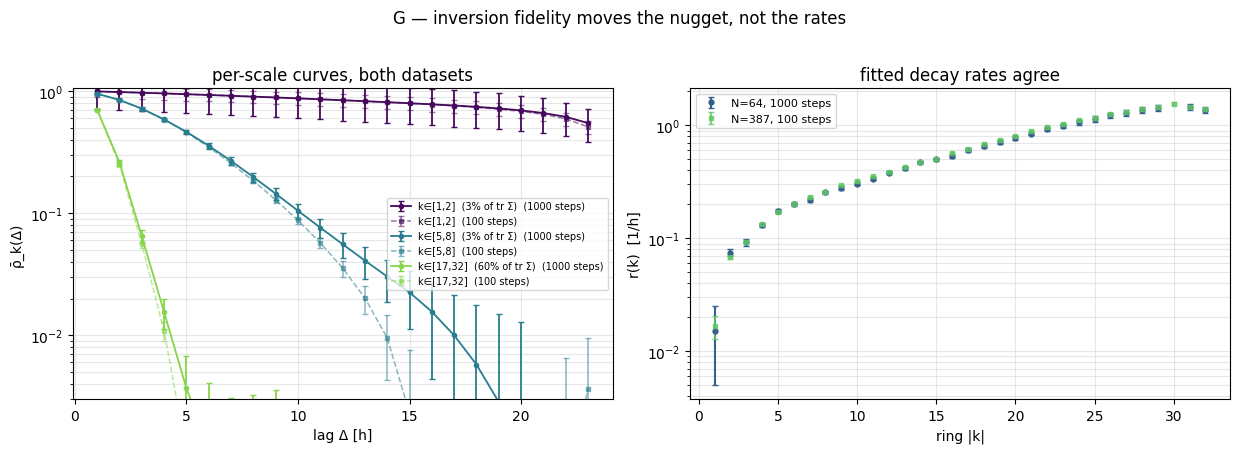

rate agreement over rings k ∈ [1, 32]:  median |Δr|/σ = 0.99,  max = 3.93 at k=16   (expected max over 31 rings under exact agreement ≈ 2.6)
mean intercept ḡ over the same rings:  1000 steps 1.711   vs   100 steps 1.736   → the short-lag shoulder is NOT an inversion artefact
ρ̄(Δ=1), k∈[1,2]:  1000 steps 0.990 ± 0.138   100 steps 0.991 ± 0.053
ρ̄(Δ=1), k∈[17,32]:  1000 steps 0.703 ± 0.005   100 steps 0.696 ± 0.002


In [9]:
# ── G. re-run the core pipeline on the 100-step / N=387 dataset ─────────────
Z2_raw, _ = load_invert(ROBUST_DIR)
N2 = Z2_raw.shape[0]
print(f"robustness set: {Z2_raw.shape}   mean {Z2_raw.mean():+.4f}   std {Z2_raw.std():.4f}")
Zc2 = Z2_raw - Z2_raw.mean(axis=0, keepdims=True)
del Z2_raw

GB2 = band_grams(Zc2)
rho_b2, se_b2, v_b2, _ = band_curves(GB2)
grp2  = group_curves(GB2)
fits2 = [fit_ring(rho_b2[b], se_b2[b]) for b in range(B)]
r_k2   = np.array([f['r']    for f in fits2])
se_rk2 = np.array([f['se_r'] for f in fits2])
g_k2   = np.array([f['g']    for f in fits2])
ok2    = np.array([b for b in range(1, K_ISO + 1) if fits2[b]['n'] >= 3])
del GB2, Zc2

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for g in [GROUPS[0], GROUPS[2], GROUPS[-1]]:
    r_, s_ = grp[g];  m_ = r_ > 0
    axes[0].errorbar(deltas[m_], r_[m_], yerr=2 * s_[m_], fmt='o-', ms=3, lw=1.3, capsize=2,
                     color=gcol[g], label=f'{glab[g]}  (1000 steps)')
    r2_, s2_ = grp2[g];  m2_ = r2_ > 0
    axes[0].errorbar(deltas[m2_], r2_[m2_], yerr=2 * s2_[m2_], fmt='s--', ms=3, lw=1.1,
                     capsize=2, color=gcol[g], alpha=0.55, label=f'k∈[{g[0]},{g[1]}]  (100 steps)')
axes[0].set_yscale('log'); axes[0].set_ylim(3e-3, 1.05)
axes[0].set_xlabel('lag Δ [h]'); axes[0].set_ylabel('ρ̄_k(Δ)')
axes[0].set_title('per-scale curves, both datasets')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3, which='both')

both = np.intersect1d(ok, ok2)
axes[1].errorbar(ok,  r_k[ok],  yerr=2 * se_rk[ok],  fmt='o', ms=3.5, capsize=2,
                 color=cmap(0.3), label='N=64, 1000 steps')
axes[1].errorbar(ok2, r_k2[ok2], yerr=2 * se_rk2[ok2], fmt='s', ms=3, capsize=2,
                 color=cmap(0.75), alpha=0.8, label='N=387, 100 steps')
axes[1].set_yscale('log')
axes[1].set_xlabel('ring |k|'); axes[1].set_ylabel('r(k)  [1/h]')
axes[1].set_title('fitted decay rates agree')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, which='both')
fig.suptitle('G — inversion fidelity moves the nugget, not the rates', y=1.02)
fig.tight_layout(); plt.show()

zdisc = np.abs(r_k[both] - r_k2[both]) / np.hypot(se_rk[both], se_rk2[both])
print(f"rate agreement over rings k ∈ [{both.min()}, {both.max()}]:  median |Δr|/σ = "
      f"{np.median(zdisc):.2f},  max = {zdisc.max():.2f} at k={both[np.argmax(zdisc)]}"
      f"   (expected max over {both.size} rings under exact agreement ≈ 2.6)")
gm, gm2 = np.nanmean(g_k[both]), np.nanmean(g_k2[both])
print(f"mean intercept ḡ over the same rings:  1000 steps {gm:.3f}   vs   100 steps {gm2:.3f}"
      + ("   → the short-lag shoulder is NOT an inversion artefact"
         if abs(gm - gm2) < 0.15 * gm else "   → fidelity-dependent: partly an inversion artefact"))
for g in [GROUPS[0], GROUPS[-1]]:
    print(f"ρ̄(Δ=1), k∈[{g[0]},{g[1]}]:  1000 steps {grp[g][0][0]:.3f} ± {grp[g][1][0]:.3f}   "
          f"100 steps {grp2[g][0][0]:.3f} ± {grp2[g][1][0]:.3f}")

## Conclusions — is the temporal correlation still learnable with $\Sigma \neq I$?

**Yes.** The spatial correlation does not break learnability — it breaks only the reading of "one scalar $\alpha(t)$ shared by all pixel coordinates". Done in the right basis (whitened modes ≈ Fourier rings), everything in Andrae §3.4–3.6 goes through, and the estimates are clean:

| question | result | consequence |
|---|---|---|
| does the §3.6 scalar estimator survive $\Sigma\neq I$? | yes — $\hat\alpha(\Delta)=\sum_k \hat w_k\bar\rho_k(\Delta)$ verified to 0.006 | $\Sigma\neq I$ biases nothing; the scalar is a power-weighted blend |
| separable — do the $\rho_k$ curves collapse (§8)? | **no — 7σ fan-out** ($k\in[1,2]$ vs $k\in[17,32]$, $\Delta\ge4$) | the learnable object is $\alpha(k,t)$, not $\alpha(t)$ |
| OLS vs GLS scalar (§3) | equal at $\Delta\le4$, split ≥3σ in the tail | $\Sigma\neq I$ costs variance, not bias — confirmed empirically |
| Gate 1 in the whitened basis | excess kurtosis +0.63 ($k\le2$) → +0.06 ($k\ge17$) | Gaussian-process machinery is safe |
| §6 consistency $c_k^2\ge0$ | no violations in any fitted ring | per-mode diffusion representation exists |
| is $c_k$ time-homogeneous (pure OU)? | no: $g_k>1$ in all 31 rings, $\tilde c^2$ rises to plateau | per-mode kernel smoother than OU at $\Delta\lesssim3$ (stationary, slightly non-Markov) |
| robust to inversion fidelity (1000 vs 100 steps)? | $r(k)$: median 1.0σ agreement; $\bar g$ 1.71 vs 1.74 | rates *and* shoulder are data properties, not inversion artefacts |

**The learned process (deliverable).** Per whitened Fourier mode: decay rate $r(k)$ rising 0.015 → 1.4 h⁻¹ from $k$=1 to 32 ($\tau_{\rm dec}$ 66 h → 0.7 h), $c_k^2 = 2r_k$; per-scale OU R² 0.81–0.97 (vs −0.03 for any scalar exponential); and, model-free, the per-ring $\alpha(k,\Delta)$ sequence itself, which §F simulates as a stationary process reproducing the empirical scalar correlation to 0.002 while preserving the equal-time marginal exactly.

**Incidental findings worth keeping (feed Thread 1).**
- The inverted-latent field is near-white in *total* power: the red excess is confined to a few large-scale modes ($k\le8$ = 6% of $\operatorname{tr}\hat\Sigma$; 50% sits above $k$=26). The doc's "large scales carry most of the variance" describes the physical field, not the latent.
- One genuinely coherent, non-stationary mode: a channel-coherent $k$=1 dipole (EOF 1 — 2.2% of $\operatorname{tr}\hat\Sigma$ alone, cross-channel coherence 0.51, held-out variance ratio 0.98), whose ring power doubles from lead 1 to 24. A specific, localisable signature of where the drift is wrong.
- The scalar $\bar\rho(1) = 0.718 \approx 0.5^{1/2} = 0.707$: the current α=0.5 sampler is calibrated at lag 1 *in the aggregate* by coincidence, mis-calibrated per scale even there (0.99 at $k\le2$ vs 0.70 at $k\ge17$), over-correlates $\Delta$=2–9 and under-correlates $\Delta\gtrsim10$.

**Caveats.** Hourly sampling leaves the $\Delta<1$ h kernel unresolved (the shoulder's shape below 1 h is unconstrained). The ring machinery pools the 2×2 cross-channel structure (coherence 0.51 at $k$=1, ~3% of $\operatorname{tr}\hat\Sigma$) — a per-$k$ channel-eigenmode refinement is cheap if it ever matters. Primary N=64; all key numbers re-checked at N=387 (§G).

**Next steps.**
1. **Deploy**: replace `get_latents`' scalar AR(1) with the per-ring process in Fourier space — sim 1 (homogeneous OU(k), ~10 lines) as the §3.5-faithful version, or sim 2's factorisation for the exact measured kernel. For forecasting, run it on whitened modes with **$\mathcal N(0,I)$ re-colouring** (keep the marginal the flow model was trained on); the $\hat\Sigma$-coloured variant is a Thread-1 experiment (noise partially compensating drift error), not the default.
2. **Validate** (recipe step 8, full): regenerate ensemble forecasts with $\alpha(k,t)$ and compare temporal-coherence diagnostics ($\Delta X$ residual spectra) plus RMSE/CRPS/SSR against α=0.5 — per-lead marginals should be untouched, temporal structure should move toward data.
3. **Kernel family** (refinement): a stationary smoother-than-OU family per mode (Matérn $\nu>\tfrac12$ / AR(2)) to absorb the $\Delta\le3$ shoulder the pure OU family cannot represent stationarily.
4. **$x_0$-dependence**: Step 2c's enstrophy-binning machinery applies per ring unchanged if $\alpha(k,t;x_0)$ becomes the question.